# Transformer Architectures

## Introduction

In the [previous notebooks](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_3_dl_sequence_modeling/0_5_self_attention_scratch.ipynb), we explored the fundamentals of self-attention and learned how to implement attention mechanisms from scratch. We developed an understanding of Query, Key, and Value vectors, scaled dot-product attention, batching, and causal masking.

The goal of this notebook is to build on that foundation and understand how these individual components are combined to create modern Transformer architectures.

Throughout this notebook, we will explore positional encoding, multi-head attention, residual connections, layer normalization, feed forward networks, and complete Transformer blocks. We will then connect these concepts to real-world models such as GPT and BERT and follow the complete pipeline from raw text to next-token prediction.

By the end of this notebook, you should be able to understand the purpose of every major component inside a Transformer model and explain how modern large language models are built from these fundamental building blocks.


# Section 1: Why Self-Attention Alone Is Not Enough

## Learning Objectives

After completing this section, you should be able to:

* Understand the limitations of self-attention without positional information.
* Explain why token order matters in natural language.
* Understand the concept of permutation invariance.
* Explain the motivation behind positional encoding.

---

## The Missing Piece

In the [previous notebooks](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_3_dl_sequence_modeling/0_5_self_attention_scratch.ipynb), we learned how self-attention allows tokens to exchange information and build context-aware representations. However, there is a fundamental problem with the attention mechanism as we have implemented it so far:

> Self-attention has no built-in notion of token order.

The attention mechanism can determine which tokens are related to each other, but it does not inherently know which token appeared first, second, or last in a sequence.

---

## Why Word Order Matters

Consider the following sentences:

```text
dog bites man
```

```text
man bites dog
```

Both sentences contain exactly the same words:

```text
dog
bites
man
```

However, their meanings are completely different.

A model that understands language must be able to distinguish between these two sequences.

---

## The Problem

Our attention implementation computes:

Q = XW_Q

K = XW_K

V = XW_V

and then:

Attention(Q,K,V)

using only the token embeddings.

If the embeddings for:

```text
dog
bites
man
```

remain the same regardless of their position in the sentence, then the model has no explicit information about order.

It knows:

```text
dog exists
bites exists
man exists
```

but it does not know:

```text
which token came first
which token came second
which token came third
```

---



## Permutation Invariance

Self-attention is naturally permutation-invariant.

This means that the mechanism itself does not care about the order of elements in the sequence.

For example:

```text
dog bites man
```

and

```text
man bites dog
```

contain the same set of tokens.

Without additional positional information, the attention mechanism has no reliable way to distinguish between these sequences.

---

## Intuition

Imagine being given a deck of cards:

```text
Ace
King
Queen
```

You know which cards are present, but not the order in which they were arranged.

The sequences:

```text
Ace King Queen
```

and

```text
Queen King Ace
```

contain the same cards but represent different orders.

The attention mechanism faces a similar problem when processing language.

---

## What Do We Need?

We need a way to tell the model:

```text
dog is in position 0
bites is in position 1
man is in position 2
```

so that:

```text
dog at position 0
```

is different from:

```text
dog at position 2
```

even though the word itself is identical.

This additional information is called **positional information**.

---

## Key Takeaways

* Self-attention can model relationships between tokens.
* Self-attention does not inherently understand token order.
* Natural language meaning depends heavily on word order.
* Transformers must explicitly inject positional information.
* Positional encoding is the mechanism used to solve this problem.

In the next section, we will explore positional encoding and learn how Transformers represent token positions without using recurrence or convolution.



---

# Section 2: Positional Encoding

## Learning Objectives

After completing this section, you should be able to:

* Understand why positional encoding is required.
* Explain how positional information is injected into embeddings.
* Implement simple positional encodings.
* Understand sinusoidal positional encoding.
* Visualize positional patterns.
* Understand why Transformers can generalize to unseen sequence lengths.

---



## 2.1 The Core Idea

We already have token embeddings:

```python
dog   -> [0.2, 0.8, 0.1, 0.4]
bites -> [0.5, 0.1, 0.7, 0.3]
man   -> [0.9, 0.2, 0.4, 0.6]
```

But they contain:

```text
semantic meaning
```

not:

```text
position information
```

The simplest idea is:

```python
input = token_embedding + positional_encoding
```

This is exactly what Transformers do.

---



## 2.2 A Simple Positional Encoding

Before looking at the real Transformer version, let's build a toy example.



In [1]:
import numpy as np

seq_len = 5
d_model = 4

# Create positions:
positions = np.arange(seq_len)

print(positions)

[0 1 2 3 4]


In [2]:
# Now create a simple encoding:
PE = np.zeros((seq_len, d_model))

for pos in range(seq_len):
    PE[pos] = pos

print(PE)

[[0. 0. 0. 0.]
 [1. 1. 1. 1.]
 [2. 2. 2. 2.]
 [3. 3. 3. 3.]
 [4. 4. 4. 4.]]


In [3]:
# random X sample
X = [
    [0.2, 0.8, 0.1, 0.4],
    [0.5, 0.1, 0.7, 0.3],
    [0.9, 0.2, 0.4, 0.6],
    [0.2, 0.2, 0.4, 0.3],
    [0.5, 0.1, 0.1, 0.3],
]

In [5]:
X_with_position = X + PE
X_with_position

array([[0.2, 0.8, 0.1, 0.4],
       [1.5, 1.1, 1.7, 1.3],
       [2.9, 2.2, 2.4, 2.6],
       [3.2, 3.2, 3.4, 3.3],
       [4.5, 4.1, 4.1, 4.3]])


Now each token carries both:

```text
meaning
+
position
```

---



### Problem With This Approach

Suppose training only saw:

```text
positions 0–100
```

What happens at:

```text
position 1000
```

?

The model may struggle to generalize.

We want something more structured.

---



## 2.3 The Transformer Solution

Instead of learning positions directly, the original Transformer paper uses:

```text
sine waves
+
cosine waves
```

of different frequencies.

---

The formulas are:

$
PE(pos,2i)=\sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$

and

$
PE(pos,2i+1)=\cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$

Don't worry about memorizing them.

Focus on understanding the behavior.

---



## 2.4 Build It From Scratch


In [ ]:
import numpy as np

def positional_encoding(seq_len, d_model):

    PE = np.zeros((seq_len, d_model))

    for pos in range(seq_len):

        for i in range(0, d_model, 2):

            denominator = 100 ** (i / d_model) # use 100 instead of 10000 here for better visualization

            PE[pos, i] = np.sin(pos / denominator)

            if i + 1 < d_model:
                PE[pos, i + 1] = np.cos(pos / denominator)

    return PE

In [14]:
# Generate an example:
PE = positional_encoding(
    seq_len=10,
    d_model=16
)

print(PE.shape)

(10, 16)


## 2.5 Visualize It

This is where the intuition appears.


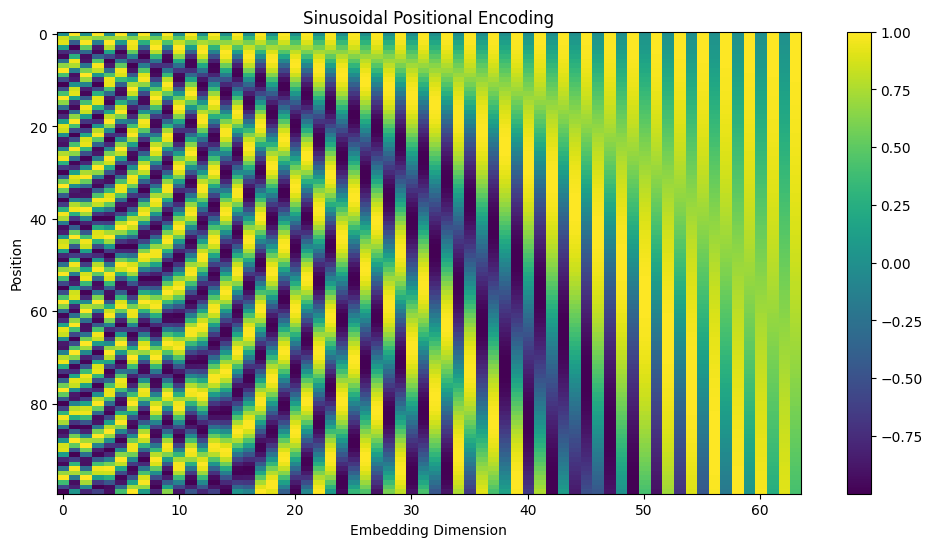

In [15]:
import matplotlib.pyplot as plt

PE = positional_encoding(
    seq_len=100,
    d_model=64
)

plt.figure(figsize=(12,6))

plt.imshow(
    PE,
    aspect="auto"
)

plt.colorbar()

plt.xlabel("Embedding Dimension")
plt.ylabel("Position")

plt.title("Sinusoidal Positional Encoding")

plt.show()

**What Do You See?**

You see:

```text
waves
```

Different dimensions oscillate at different frequencies.

Some dimensions:

```text
change quickly
```

Others:

```text
change slowly
```

---


### Why Multiple Frequencies?

Think about music.

One sine wave can encode:

```text
a single rhythm
```

Many sine waves can encode:

```text
rich patterns
```

The Transformer uses many frequencies so every position gets a unique signature.

---



## 2.6 Important Property

Every position gets a unique vector.

For example:

```python
PE[5]
```

is different from:

```python
PE[6]
```

and

```python
PE[50]
```

and

```python
PE[500]
```

---

This allows the model to distinguish:

```text
dog at position 0
```

from:

```text
dog at position 7
```

even though the word embedding is identical.

---



## 2.7 Combining With Embeddings

Suppose:

```python
X.shape
```

is:

```python
(seq_len, d_model)
```

and:

```python
PE.shape
```

is:

```python
(seq_len, d_model)
```

Then:

```python
X_input = X + PE
```

Shape:

```python
(seq_len, d_model)
```

unchanged.

---

The transformer then receives:

```text
semantic information
+
position information
```

in a single vector.

---



## Section Summary

* Self-attention alone does not understand order.
* Transformers inject positional information into embeddings.
* The original Transformer uses sinusoidal positional encoding.
* Different dimensions use different frequencies.
* Position and meaning are combined through simple vector addition.
* Positional encodings allow the model to distinguish identical words appearing at different locations.

# Section 3: Multi-Head Attention

## Learning Objectives

After completing this section, you should be able to:

* Understand the motivation behind multi-head attention.
* Explain why a single attention mechanism is often insufficient.
* Understand how multiple attention heads operate in parallel.
* Implement a simple multi-head attention mechanism.
* Understand how head outputs are combined.

---



## Why One Attention Head Is Not Enough

In the [previous notebooks](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_3_dl_sequence_modeling/0_5_self_attention_scratch.ipynb), we implemented a single self-attention mechanism.

Conceptually, a single attention head can learn one dominant type of relationship between tokens.

For example:

```text
The cat chased the mouse
```

A single head might learn to focus on:

```text
cat ↔ chased
```

However, language contains many different types of relationships simultaneously:

```text
subject ↔ verb
verb ↔ object
long-range dependencies
positional relationships
coreferences
semantic similarity
```

Ideally, we would like the model to analyze several of these relationships at the same time.

---



## The Core Idea

Instead of computing one attention operation:

```text
Attention(Q,K,V)
```

we compute several independent attention operations in parallel.

For example:

```text
Head 1 → grammatical relationships
Head 2 → semantic relationships
Head 3 → positional relationships
Head 4 → long-range dependencies
```

Each head learns its own Query, Key, and Value projections.

---



## Architecture Overview

Single-head attention:

```text
Input
  │
  ▼
Attention
  │
  ▼
Output
```

Multi-head attention:

```text
Input
  │
  ├──── Head 1
  ├──── Head 2
  ├──── Head 3
  └──── Head 4
          │
          ▼
      Concatenate
          │
          ▼
     Linear Layer
          │
          ▼
        Output
```

---



## Head Dimensions

Suppose:


In [16]:
d_model = 128
num_heads = 4

Then:

In [17]:
head_dim = d_model // num_heads
head_dim

32


Each head receives:

```text
128-dimensional input
```

but performs attention in a:

```text
32-dimensional subspace
```

---


## Why Split the Embedding?

Without splitting:

```text
4 heads × 128 dimensions
```

would quadruple the computation.

Instead:

```text
4 heads × 32 dimensions
```

keeps the computational cost roughly similar while allowing the model to learn multiple attention patterns.

---




## A Simple Multi-Head Example

Let's build a minimal implementation.

In [18]:
import numpy as np

np.random.seed(42)

seq_len = 3
d_model = 8
num_heads = 2

X = np.random.randn(seq_len, d_model)

head_dim = d_model // num_heads

In [ ]:
# Split Into Heads
X_heads = X.reshape(
    seq_len,
    num_heads,
    head_dim
)

print(X_heads.shape)

(3, 2, 4)


```text
3 tokens
2 attention heads
4 dimensions per head
```

**Visualizing the Split**

Original embedding:

```text
Token
[1 2 3 4 5 6 7 8]
```

Head split:

```text
Head 1
[1 2 3 4]

Head 2
[5 6 7 8]
```

Each head receives a different portion of the representation space.

---



## Simplified Multi-Head Attention

The real Transformer learns separate projection matrices for each head.

Conceptually:

```python
head1 = Attention(Q1, K1, V1)

head2 = Attention(Q2, K2, V2)

...

headN = Attention(QN, KN, VN)
```

Each head produces its own output.

---



## Concatenation

After computing all heads:

```python
multi_head_output = np.concatenate(
    [head1, head2,..., headN],
    axis=-1
)
```

Example:

```text
Head 1 output shape:
(3,4)

Head 2 output shape:
(3,4)
```

After concatenation:

```text
(3,8)
```

which restores the original embedding dimension.

---



## Final Linear Projection

The Transformer then applies one additional learned matrix:

```python
output = multi_head_output @ W_O
```

This allows information from different heads to interact.

---



**Intuition**

Think of a sentence:

```text
The cat chased the mouse
```

Different heads may focus on different aspects:

```text
Head 1:
cat ↔ chased

Head 2:
chased ↔ mouse

Head 3:
The ↔ cat

Head 4:
sentence-level context
```

No single head needs to learn everything.

The work is distributed across multiple specialists.

---



## Why Multi-Head Attention Works

A single attention head produces one view of the sequence.

Multiple heads allow the model to create several independent views simultaneously.

This dramatically increases the representational power of the Transformer while preserving parallel computation.

---


## Section Summary

* Multi-head attention runs several attention mechanisms in parallel.
* Each head learns different relationships between tokens.
* The embedding dimension is split across heads.
* Head outputs are concatenated and projected back to the model dimension.
* Multi-head attention is one of the key innovations that makes Transformers so powerful.

# Section 4: Residual Connections & Layer Normalization

## Learning Objectives

After completing this section, you should be able to:

* Understand why deep neural networks are difficult to train.
* Explain the purpose of residual connections.
* Understand how Layer Normalization stabilizes training.
* Explain the "Add & Norm" blocks in Transformer diagrams.
* Understand how these components work together inside a Transformer block.

---


## Why Do We Need Additional Components?

So far, we have built increasingly powerful attention mechanisms:

```text
Positional Encoding
        ↓
Multi-Head Attention
```

At first glance, it might seem that stacking many attention layers should be enough.

However, deep neural networks suffer from several problems:

* Information can gradually degrade as it passes through many layers.
* Gradients can become unstable during training.
* Learning becomes slower and less reliable.

Transformers solve these issues using two important techniques:

```text
Residual Connections
+
Layer Normalization
```

---




## Residual Connections

The idea is surprisingly simple.

Instead of replacing the input with the attention output:

```text
Input
  ↓
Attention
  ↓
Output
```

we add the original input back:

```text
Input ───────────┐
                │
                ▼
            Attention
                │
                ▼
           Add(Input)
                │
                ▼
             Output
```

Mathematically:

y=x+f(x)

where:

* `x` is the original input
* `f(x)` is the attention output

---



**Intuition**

Imagine reading a book summary.

You could:

```text
Replace the entire book
with the summary
```

or:

```text
Keep the original book
and add the summary notes
```

Residual connections follow the second approach.

The model preserves the original information while incorporating new information learned by attention.

---


**Example**

Suppose:

In [20]:
x = np.array([1.0, 2.0, 3.0])

attention_output = np.array([0.2, -0.5, 0.8])

Residual connection:

In [21]:
y = x + attention_output

print(y)

[1.2 1.5 3.8]


The original information is still present.


### Why Residual Connections Help

Without residuals:

```text
Layer 1
  ↓
Layer 2
  ↓
Layer 3
  ↓
...
```

Each layer must completely reconstruct useful information.

With residuals:

```text
Layer 1
  ↓
+ Input
  ↓
Layer 2
  ↓
+ Input
  ↓
Layer 3
```

Information can flow directly through the network.

This significantly improves training of deep models.

---



## Layer Normalization

Even with residual connections, activations can become unstable.

For example:

```python
[0.1, 0.2, 0.3]
```

might become:

```python
[10.0, -15.0, 27.0]
```

after several transformations.

Large variations make training difficult.

---


### The Solution

Normalize the values.

Layer Normalization computes:

1. Mean
2. Standard deviation
3. Normalized output

Conceptually:

```text
Input Values
      ↓
Normalize
      ↓
Stable Values
```

---

Simple Example:

In [22]:
import numpy as np

x = np.array([1.0, 2.0, 3.0])

mean = np.mean(x)
std = np.std(x)

normalized = (x - mean) / std

print(normalized)

[-1.22474487  0.          1.22474487]



### Why LayerNorm Matters

Layer Normalization helps:

* Stabilize activations
* Improve gradient flow
* Speed up training
* Make deep Transformers possible

Without normalization, very deep Transformer networks become much harder to train.

---



## Add & Norm

In Transformer diagrams you often see:

```text
Add & Norm
```

This is actually two operations:

```text
Attention Output
        +
Original Input
        ↓
LayerNorm
```

Mathematically:

```text
LayerNorm(x + Attention(x))
```

---



### Transformer Block Pattern

After Multi-Head Attention:

```text
Input
  │
  ▼
Multi-Head Attention
  │
  ▼
Add & Norm
```

After Feed Forward Network:

```text
Input
  │
  ▼
Feed Forward
  │
  ▼
Add & Norm
```

This pattern repeats throughout the entire Transformer.

---



### Visual Summary

```text
Input
  │
  ▼
Multi-Head Attention
  │
  ▼
Add (Residual)
  │
  ▼
LayerNorm
  │
  ▼
Feed Forward
  │
  ▼
Add (Residual)
  │
  ▼
LayerNorm
  │
  ▼
Output
```

---


## Section Summary

* Residual connections preserve information and improve gradient flow.
* Layer Normalization stabilizes activations during training.
* Residual connections and LayerNorm appear throughout Transformer architectures.
* "Add & Norm" is one of the most common patterns in Transformer blocks.
* These techniques enable Transformers to scale to dozens or even hundreds of layers.

In [23]:
x = np.array([1, 2, 3])

f_x = np.array([0.5, -1, 0.5])

x + f_x

array([1.5, 1. , 3.5])

# Section 5: Feed Forward Networks (FFN)

## Learning Objectives

After completing this section, you should be able to:

* Understand the role of Feed Forward Networks (FFNs) in Transformer blocks.
* Explain why attention alone is not sufficient.
* Understand the structure of a Transformer FFN.
* Implement a simple FFN using NumPy.
* Understand how FFNs complement attention mechanisms.

---



## Attention Is Not the Whole Transformer

Many people initially think that Transformers are simply stacks of attention layers.

In reality, every Transformer block contains two major computational components:

```text
Multi-Head Attention
+
Feed Forward Network (FFN)
```

A simplified Transformer block looks like:

```text
Input
  │
  ▼
Multi-Head Attention
  │
  ▼
Add & Norm
  │
  ▼
Feed Forward Network
  │
  ▼
Add & Norm
  │
  ▼
Output
```

---



## What Does Attention Do?

Attention allows tokens to exchange information.

For example:

```text
The cat chased the mouse
```

Attention helps the model learn relationships such as:

```text
cat ↔ chased
chased ↔ mouse
```

However, attention itself is mostly an information-routing mechanism.

It determines:

```text
Who should listen to whom?
```

but it does not perform much transformation of the information itself.

---



## What Does the FFN Do?

The Feed Forward Network processes each token independently and transforms its representation into a richer feature space.

Conceptually:

```text
Attention
    ↓
Gather information
    ↓
FFN
    ↓
Process information
```

You can think of FFNs as the component that allows the model to reason about and transform the information gathered through attention.

---


## FFN Architecture

A typical Transformer FFN consists of:

```text
Linear
  ↓
Activation Function
  ↓
Linear
```

Modern Transformers often use:

```text
Linear
  ↓
GELU
  ↓
Linear
```

---


### Example Dimensions

Suppose:

```python
d_model = 512
```

A typical FFN expands the representation:

```text
512
 ↓
2048
 ↓
512
```

This is often written as:

```python
512 → 2048 → 512
```

Notice that the middle layer is much larger.

This gives the network additional capacity to learn complex transformations.

---

## Why Expand the Dimension?

Imagine trying to solve a complex problem.

Sometimes it helps to:

```text
Expand the information
↓
Process it
↓
Compress it back
```

The FFN follows the same idea.

The intermediate layer creates a larger feature space where richer transformations can occur.

---


## Simple NumPy Example


In [9]:
import numpy as np

np.random.seed(42)

x = np.array([
    [1.0, 2.0, 3.0, 4.0]
])

print(f'\INPUT:{40*"-"}')
print(x.shape)
print(x)

W1 = np.random.randn(4, 8)
W2 = np.random.randn(8, 4)

hidden = x @ W1

print(f'\nHIDDEN LAYER:{40*"-"}')
print(hidden.shape)
print(f'before activation: {hidden.round(2)}')

hidden = np.maximum(0, hidden)  # ReLU

print(f'after activation: {hidden.round(2)}')

output = hidden @ W2

print(f'\nOUTPUT:{40*"-"}')
print(output.shape)
print(output)

\INPUT:----------------------------------------
(1, 4)
[[1. 2. 3. 4.]]

HIDDEN LAYER:----------------------------------------
(1, 8)
before activation: [[-5.66  2.33 -7.61 -2.14  2.24 -5.9  -4.07  2.78]]
after activation: [[0.   2.33 0.   0.   2.24 0.   0.   2.78]]

OUTPUT:----------------------------------------
(1, 4)
[[-0.07254132 -9.04473416 -5.44484107 -3.72758976]]


The input and output dimensions match, making the FFN compatible with residual connections.


---

## Activation Functions

Without an activation function:

```text
Linear
 ↓
Linear
```

would still be equivalent to a single linear transformation.

The activation function introduces non-linearity.

Common choices:

```text
ReLU
GELU
SiLU
```

Modern Transformer models most commonly use:

```text
GELU
```

---



## FFN and Tokens

An important observation:

Unlike attention:

```text
Token A ↔ Token B
```

the FFN does not mix information between tokens.

Instead:

```text
Token A → FFN(Token A)

Token B → FFN(Token B)

Token C → FFN(Token C)
```

Each token is processed independently.

---



## Attention vs FFN

A useful mental model:

| Component | Purpose                                          |
| --------- | ------------------------------------------------ |
| Attention | Exchange information between tokens              |
| FFN       | Process and transform information within a token |

Together they form the core computational engine of a Transformer.

---

**Visual Summary**

```text
Attention:
Who should I listen to?

FFN:
What should I do with the information I received?
```

---


## Section Summary

* Every Transformer block contains both Attention and FFN layers.
* Attention exchanges information between tokens.
* FFNs transform token representations independently.
* FFNs typically expand and then compress the feature dimension.
* Activation functions introduce non-linear transformations.
* Attention and FFNs work together to create powerful Transformer representations.

# Section 6: Building a Complete Transformer Block

## Learning Objectives

After completing this section, you should be able to:

* Understand the structure of a Transformer block.
* Explain how all Transformer components interact.
* Trace the flow of data through a complete block.
* Implement a simplified Transformer block.
* Understand the foundation of GPT-style architectures.

---

## Putting Everything Together

At this point we have learned:

```text
Positional Encoding
Multi-Head Attention
Residual Connections
Layer Normalization
Feed Forward Networks
```

A Transformer block combines these components into a single reusable unit.

The original Transformer architecture is built by stacking many such blocks on top of each other.

---



## Transformer Block Architecture

A simplified Transformer block looks like:

```text
Input
  │
  ▼
Multi-Head Attention
  │
  ▼
Add & Norm
  │
  ▼
Feed Forward Network
  │
  ▼
Add & Norm
  │
  ▼
Output
```

This pattern repeats throughout the model.

---



## Step 1 — Multi-Head Attention

Input tokens first interact through attention:

```text
cat
sees
dog
```

Attention allows tokens to exchange information:

```text
cat ↔ sees
sees ↔ dog
cat ↔ dog
```

The result is a context-aware representation of every token.

---



## Step 2 — Residual Connection

Instead of replacing the input:

```text
Output = Attention(x)
```

we preserve the original information:

```text
Output = x + Attention(x)
```

This helps information flow through deep networks.

---



## Step 3 — Layer Normalization

After adding the residual:

```text
x + Attention(x)
```

we normalize:

```text
LayerNorm(x + Attention(x))
```

This keeps activations stable and improves training.

---



## Step 4 — Feed Forward Network

Each token is then processed independently:

```text
Token A → FFN(Token A)

Token B → FFN(Token B)

Token C → FFN(Token C)
```

The FFN transforms the information gathered through attention.

---



## Step 5 — Another Residual Connection

Again, we preserve the previous representation:

```text
Output = x + FFN(x)
```

---

## Step 6 — Another LayerNorm

Finally:

```text
LayerNorm(x + FFN(x))
```

produces the block output.

---



## Complete Formula

Conceptually:

```text
x
 ↓
Attention
 ↓
Add & Norm
 ↓
FFN
 ↓
Add & Norm
 ↓
Output
```

or:

```text
y = LayerNorm(
        x + Attention(x)
    )

z = LayerNorm(
        y + FFN(y)
    )
```

---


## Simplified NumPy Implementation


In [25]:
import numpy as np

def layer_norm(x, eps=1e-5):
    mean = np.mean(x, axis=-1, keepdims=True)
    std = np.std(x, axis=-1, keepdims=True)

    return (x - mean) / (std + eps)

def relu(x):
    return np.maximum(0, x)

class FeedForward:

    def __init__(self, d_model, d_ff):

        self.W1 = np.random.randn(d_model, d_ff)
        self.W2 = np.random.randn(d_ff, d_model)

    def forward(self, x):

        hidden = relu(x @ self.W1)

        return hidden @ self.W2

## Transformer Block Skeleton

In [26]:
class TransformerBlock:

    def __init__(self, attention_layer, d_model, d_ff):

        self.attention = attention_layer
        self.ffn = FeedForward(
            d_model,
            d_ff
        )

    def forward(self, x):

        # Attention
        attention_output, _ = self.attention.forward(x)

        # Add & Norm
        x = layer_norm(
            x + attention_output
        )

        # FFN
        ffn_output = self.ffn.forward(x)

        # Add & Norm
        output = layer_norm(
            x + ffn_output
        )

        return output

## Why Stacking Works

One block:

```text
Basic contextual understanding
```

Twelve blocks:

```text
Richer contextual understanding
```

Forty-eight blocks:

```text
Complex hierarchical representations
```

Each block refines the representations produced by the previous one.

---



## GPT Perspective

GPT models are essentially:

```text
Token Embeddings
        +
Positional Encoding
        ↓
Transformer Block
        ↓
Transformer Block
        ↓
Transformer Block
        ↓
...
        ↓
Next Token Prediction
```

The same block is repeated many times.

---





* A Transformer block combines attention and feed-forward computation.
* Attention enables communication between tokens.
* FFNs transform token representations independently.
* Residual connections preserve information flow.
* LayerNorm stabilizes training.
* Modern Transformer models are built by stacking many identical Transformer blocks.


# Section 7: GPT Architecture: Putting Everything Together

## Learning Objectives

After completing this section, you should be able to:

* Understand the complete GPT inference pipeline.
* Explain how GPT generates text one token at a time.
* Connect all previously learned Transformer components.
* Understand the role of causal masking in text generation.
* Understand what happens between user input and model output.

---



## From Transformer Block to GPT

In the previous section, we built a complete Transformer block:

```text
Input
  ↓
Multi-Head Attention
  ↓
Add & Norm
  ↓
Feed Forward Network
  ↓
Add & Norm
  ↓
Output
```

GPT is essentially:

```text
Many Transformer Blocks
+
Token Prediction Head
```

stacked together.

---



## High-Level GPT Pipeline

When a user writes:

```text
The cat sat on the
```

GPT performs:

```text
Text
 ↓
Tokenization
 ↓
Embeddings
 ↓
Positional Encoding
 ↓
Transformer Blocks
 ↓
Prediction Layer
 ↓
Next Token
```

The process then repeats until the response is complete.

---



## Step 1 — Tokenization

GPT does not process raw text directly.

Instead:

```text
"The cat sat on the"
```

is converted into tokens.

Example:

```text
["The", "cat", "sat", "on", "the"]
```

which are then converted into IDs:

```python
[523, 1842, 7812, 391, 262]
```

These IDs become the model input.

---



## Step 2 — Token Embeddings

Each token ID is mapped to a dense vector:

```python
523  -> [ ... ]
1842 -> [ ... ]
7812 -> [ ... ]
```

Result:

```python
X.shape = (seq_len, d_model)
```

For example:

```python
(5, 768)
```

These vectors contain semantic information.

---



## Step 3 — Positional Encoding

Since attention does not understand order, positional information is added:

```python
X_input = Embeddings + PositionEncoding
```

Now the model knows:

```text
The  -> position 0
cat  -> position 1
sat  -> position 2
...
```

---



## Step 4 — Transformer Blocks

The sequence enters the first Transformer block.

Inside each block:

```text
Multi-Head Attention
 ↓
Add & Norm
 ↓
Feed Forward Network
 ↓
Add & Norm
```

This process repeats many times.

Example:

```text
Block 1
 ↓
Block 2
 ↓
Block 3
 ...
 ↓
Block 48
```

Each block refines the token representations.

---



## Step 5 — Causal Masking

More about causal masking can be found in corresponding section of [previous notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_3_dl_sequence_modeling/0_5_self_attention_scratch.ipynb)

GPT is an autoregressive model.

When predicting:

```text
The cat sat on the ?
```

the model may attend only to:

```text
The
cat
sat
on
the
```

and not future tokens.

This is enforced by causal masking.

Visualization:

```text
✓ ✗ ✗ ✗ ✗
✓ ✓ ✗ ✗ ✗
✓ ✓ ✓ ✗ ✗
✓ ✓ ✓ ✓ ✗
✓ ✓ ✓ ✓ ✓
```

This prevents the model from cheating during training.

---



## Step 6 — Prediction Layer

After the final Transformer block:

```python
Hidden States
```

are projected into:

```python
Vocabulary Scores
```

Example:

```text
Token          Score
--------------------
mat             8.5
floor           5.2
chair           2.1
banana         -1.0
```

These scores are called **logits**.

---



## Step 7 — Softmax

The logits are converted into probabilities:

```text
mat     85%
floor   10%
chair    4%
banana   1%
```

The model now has a probability distribution over the vocabulary.

---



## Step 8 — Select Next Token

GPT chooses the next token.

For example:

```text
The cat sat on the mat
```

The new token is appended:

```text
The cat sat on the mat
```

and the entire process runs again.

---



## The Generation Loop

GPT repeatedly performs:

```text
Current Tokens
      ↓
Transformer
      ↓
Predict Next Token
      ↓
Append Token
      ↓
Repeat
```

until:

* maximum length is reached
* end-of-sequence token is produced
* generation is stopped

---

## Visual Summary

```text
User Input
      ↓
Tokenization
      ↓
Token Embeddings
      ↓
Positional Encoding
      ↓
Transformer Block
      ↓
Transformer Block
      ↓
Transformer Block
      ↓
...
      ↓
Vocabulary Projection
      ↓
Softmax
      ↓
Next Token
      ↓
Repeat
```

---



## Why GPT Works

Every Transformer block performs two important tasks:

```text
Attention
→ Gather information

FFN
→ Process information
```

By stacking many blocks, GPT gradually builds increasingly sophisticated representations of the input sequence.

Early layers may learn:

```text
Grammar
```

Middle layers:

```text
Sentence structure
```

Later layers:

```text
Meaning and reasoning patterns
```

---



## Section Summary

* GPT is a stack of Transformer blocks.
* Input text is converted into tokens and embeddings.
* Positional information is added before attention.
* Causal masking prevents future-token access.
* Transformer blocks repeatedly refine token representations.
* A prediction layer produces vocabulary scores.
* Softmax converts scores into probabilities.
* GPT generates text one token at a time.


# Section 8: Encoder vs Decoder: BERT vs GPT

## Learning Objectives

After completing this section, you should be able to:

* Understand the difference between encoder and decoder architectures.
* Explain why BERT and GPT behave differently.
* Understand the role of bidirectional and causal attention.
* Recognize that both models are built on the same Transformer foundation.

---

## One Architecture, Two Approaches

The original Transformer introduced two major components:

```text
Encoder
Decoder
```

Modern language models are typically based on one of them.

---

## Encoder Models (BERT)

Encoder models use **bidirectional attention**.

This means that a token can attend to both past and future tokens.

Example:

```text
The cat sat on the mat
```

When processing:

```text
sat
```

BERT can look at:

```text
The
cat
sat
on
the
mat
```

all at once.

This makes encoder models very good for:

* Text classification
* Sentiment analysis
* Named entity recognition
* Question answering

---

## Decoder Models (GPT)

Decoder models use **causal attention**.

A token can attend only to itself and previous tokens.

Example:

```text
The cat sat on the
```

When predicting the next token, GPT can only see:

```text
The
cat
sat
on
the
```

and cannot look into the future.

This makes decoder models ideal for:

* Text generation
* Chatbots
* Code generation
* Content creation

---

## Visual Comparison

### BERT (Encoder)

```text
✓ ✓ ✓ ✓ ✓
✓ ✓ ✓ ✓ ✓
✓ ✓ ✓ ✓ ✓
✓ ✓ ✓ ✓ ✓
✓ ✓ ✓ ✓ ✓
```

Every token can attend to every other token.

---

### GPT (Decoder)

```text
✓ ✗ ✗ ✗ ✗
✓ ✓ ✗ ✗ ✗
✓ ✓ ✓ ✗ ✗
✓ ✓ ✓ ✓ ✗
✓ ✓ ✓ ✓ ✓
```

Tokens can only attend to the past.

---

## The Big Picture

Despite their differences, both architectures use the same fundamental building blocks:

```text
Token Embeddings
+
Positional Encoding
+
Multi-Head Attention
+
Feed Forward Networks
+
Residual Connections
+
Layer Normalization
```

The main difference is **how attention is applied**.

---

## Section Summary

* BERT is based on the Transformer Encoder.
* GPT is based on the Transformer Decoder.
* BERT uses bidirectional attention.
* GPT uses causal (masked) attention.
* Encoder models are optimized for understanding text.
* Decoder models are optimized for generating text.
* Both architectures are built from the same Transformer components.


# Conclusion

In this notebook, we explored how modern Transformer architectures are built from a small set of powerful ideas.

We learned why positional encoding is necessary, how multi-head attention allows the model to capture different relationships simultaneously, and how residual connections, layer normalization, and feed forward networks make deep Transformer models stable and effective.

We then combined these components into a complete Transformer block and followed the entire GPT pipeline from raw text to next-token prediction. Finally, we compared encoder-based models such as BERT with decoder-based models such as GPT and understood how they are built on the same foundation.

By the end of this notebook, a Transformer is no longer a black box. We can understand the purpose of every major component and explain how they work together to enable modern large language models.

This completes our introduction to self-attention and Transformer architectures and provides a strong foundation for studying real-world implementations and training techniques.
